In [782]:
# importing both datasets from the GitHub repo
import pandas as pd

FBI_data_url = "https://raw.githubusercontent.com/tommytoxic21/Crime_Housing_Data_Analysis/refs/heads/main/FBI_NJ_Crime_Statistics.csv"
US_Census_Bureau_url = "https://raw.githubusercontent.com/tommytoxic21/Crime_Housing_Data_Analysis/refs/heads/main/US_Census_Bureau_Housing_Characteristics.csv"

FBI = pd.read_csv(FBI_data_url)
US_Census_Bureau = pd.read_csv(US_Census_Bureau_url)

In [783]:
# preprocessing and cleaning the data

# removing the first 3 rows and the last row of the FBI dataset as these are unimportant metadata
FBI = FBI.iloc[3:-1]

# setting row 0 to the column headers to get more accurate column titles
FBI.columns = FBI.iloc[0]
FBI = FBI[1:]

# removing \n in FBI columns and the 1 in the "Rape" column
FBI.columns = FBI.columns.str.replace("\n",' ', regex=True)
FBI.columns = FBI.columns.str.replace("1",'', regex=True)

# removing the margin of error columns from the US Census Bureau dataset since a majority of them are negligble
US_Census_Bureau = US_Census_Bureau.loc[:, ~US_Census_Bureau.columns.str.endswith("M")]
US_Census_Bureau = US_Census_Bureau.loc[:, ~US_Census_Bureau.columns.str.endswith("PE")]

# setting row 0 to the column headers to get more accurate column titles rather than numbers
US_Census_Bureau.columns = US_Census_Bureau.iloc[0]
US_Census_Bureau = US_Census_Bureau[1:]

# simplfying column title descriptions to remove anything before "!!"
US_Census_Bureau.columns = US_Census_Bureau.columns.str.split("!!").str[-1]

# remove the last column as it is only NaN
US_Census_Bureau = US_Census_Bureau.iloc[:, :-1]

# removing any area with "CDP" as this will not be found in the FBI dataset
US_Census_Bureau = US_Census_Bureau[~US_Census_Bureau["Geographic Area Name"].str.contains("CDP", case=False, na=False)]

# removing ", New Jersey", " city", " borough"
US_Census_Bureau["Geographic Area Name"] = US_Census_Bureau["Geographic Area Name"].str.replace(", New Jersey",'', regex=True)
US_Census_Bureau["Geographic Area Name"] = US_Census_Bureau["Geographic Area Name"].str.replace(" city",'', regex=True)
US_Census_Bureau["Geographic Area Name"] = US_Census_Bureau["Geographic Area Name"].str.replace(" borough",'', regex=True)

# remove certain duplicate columns like total housing units and occupied housing units
delete_duplicates = ['Total housing units', 'Occupied housing units', 'Owner-occupied units', 'Housing units with a mortgage']
mask = US_Census_Bureau.columns.isin(delete_duplicates) & US_Census_Bureau.columns.duplicated()
US_Census_Bureau = US_Census_Bureau.loc[:, ~mask]

# change the name of rent prices columns to differentiate from other similar columns
US_Census_Bureau.columns.values[116] = "Less than $500 (rent)"
US_Census_Bureau.columns.values[117] = "$500 to $999 (rent)"
US_Census_Bureau.columns.values[118] = "$1,000 to $1,499 (rent)"
US_Census_Bureau.columns.values[119] = "$1,500 to $1,999 (rent)"
US_Census_Bureau.columns.values[120] = "$2,000 to $2,499 (rent)"
US_Census_Bureau.columns.values[121] = "$2,500 to $2,999 (rent)"
US_Census_Bureau.columns.values[122] = "$3,000 or more (rent)"

In [784]:
# merging the two datasets on city and geographic area name
# note: some towns appear in 1 dataset, but not the other, and vice versa
#       so the data after merging will be smaller
# also, convert every value to numeric for ease of access later
merged_df = pd.merge(FBI, US_Census_Bureau, left_on='City', right_on='Geographic Area Name', how='inner')

# renaming duplicate column names
merged_df.columns = pd.Series(merged_df.columns).where(
    ~pd.Series(merged_df.columns).duplicated(),
    pd.Series(merged_df.columns) + "_" + pd.Series(merged_df.columns).groupby(merged_df.columns).cumcount().astype(str)
)

# replace missin values with NaN
merged_df = merged_df.replace('-', pd.NA)

# get every column other than city, geographic area name, and geography
cols = merged_df.columns.difference(['City', 'Geographic Area Name', 'Geography'])

# remove commas and convert the strings to numeric values
for col in cols:
    merged_df[col] = (
        merged_df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
    )
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

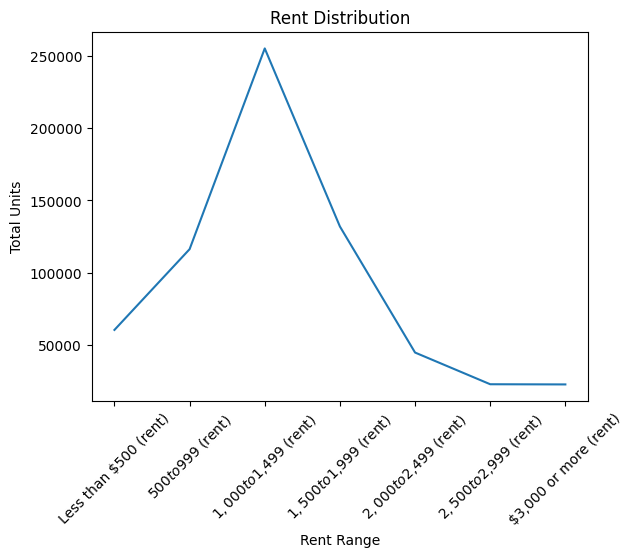

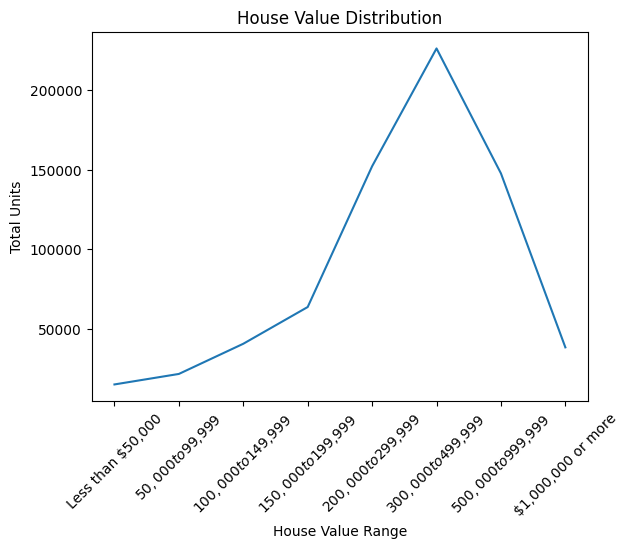

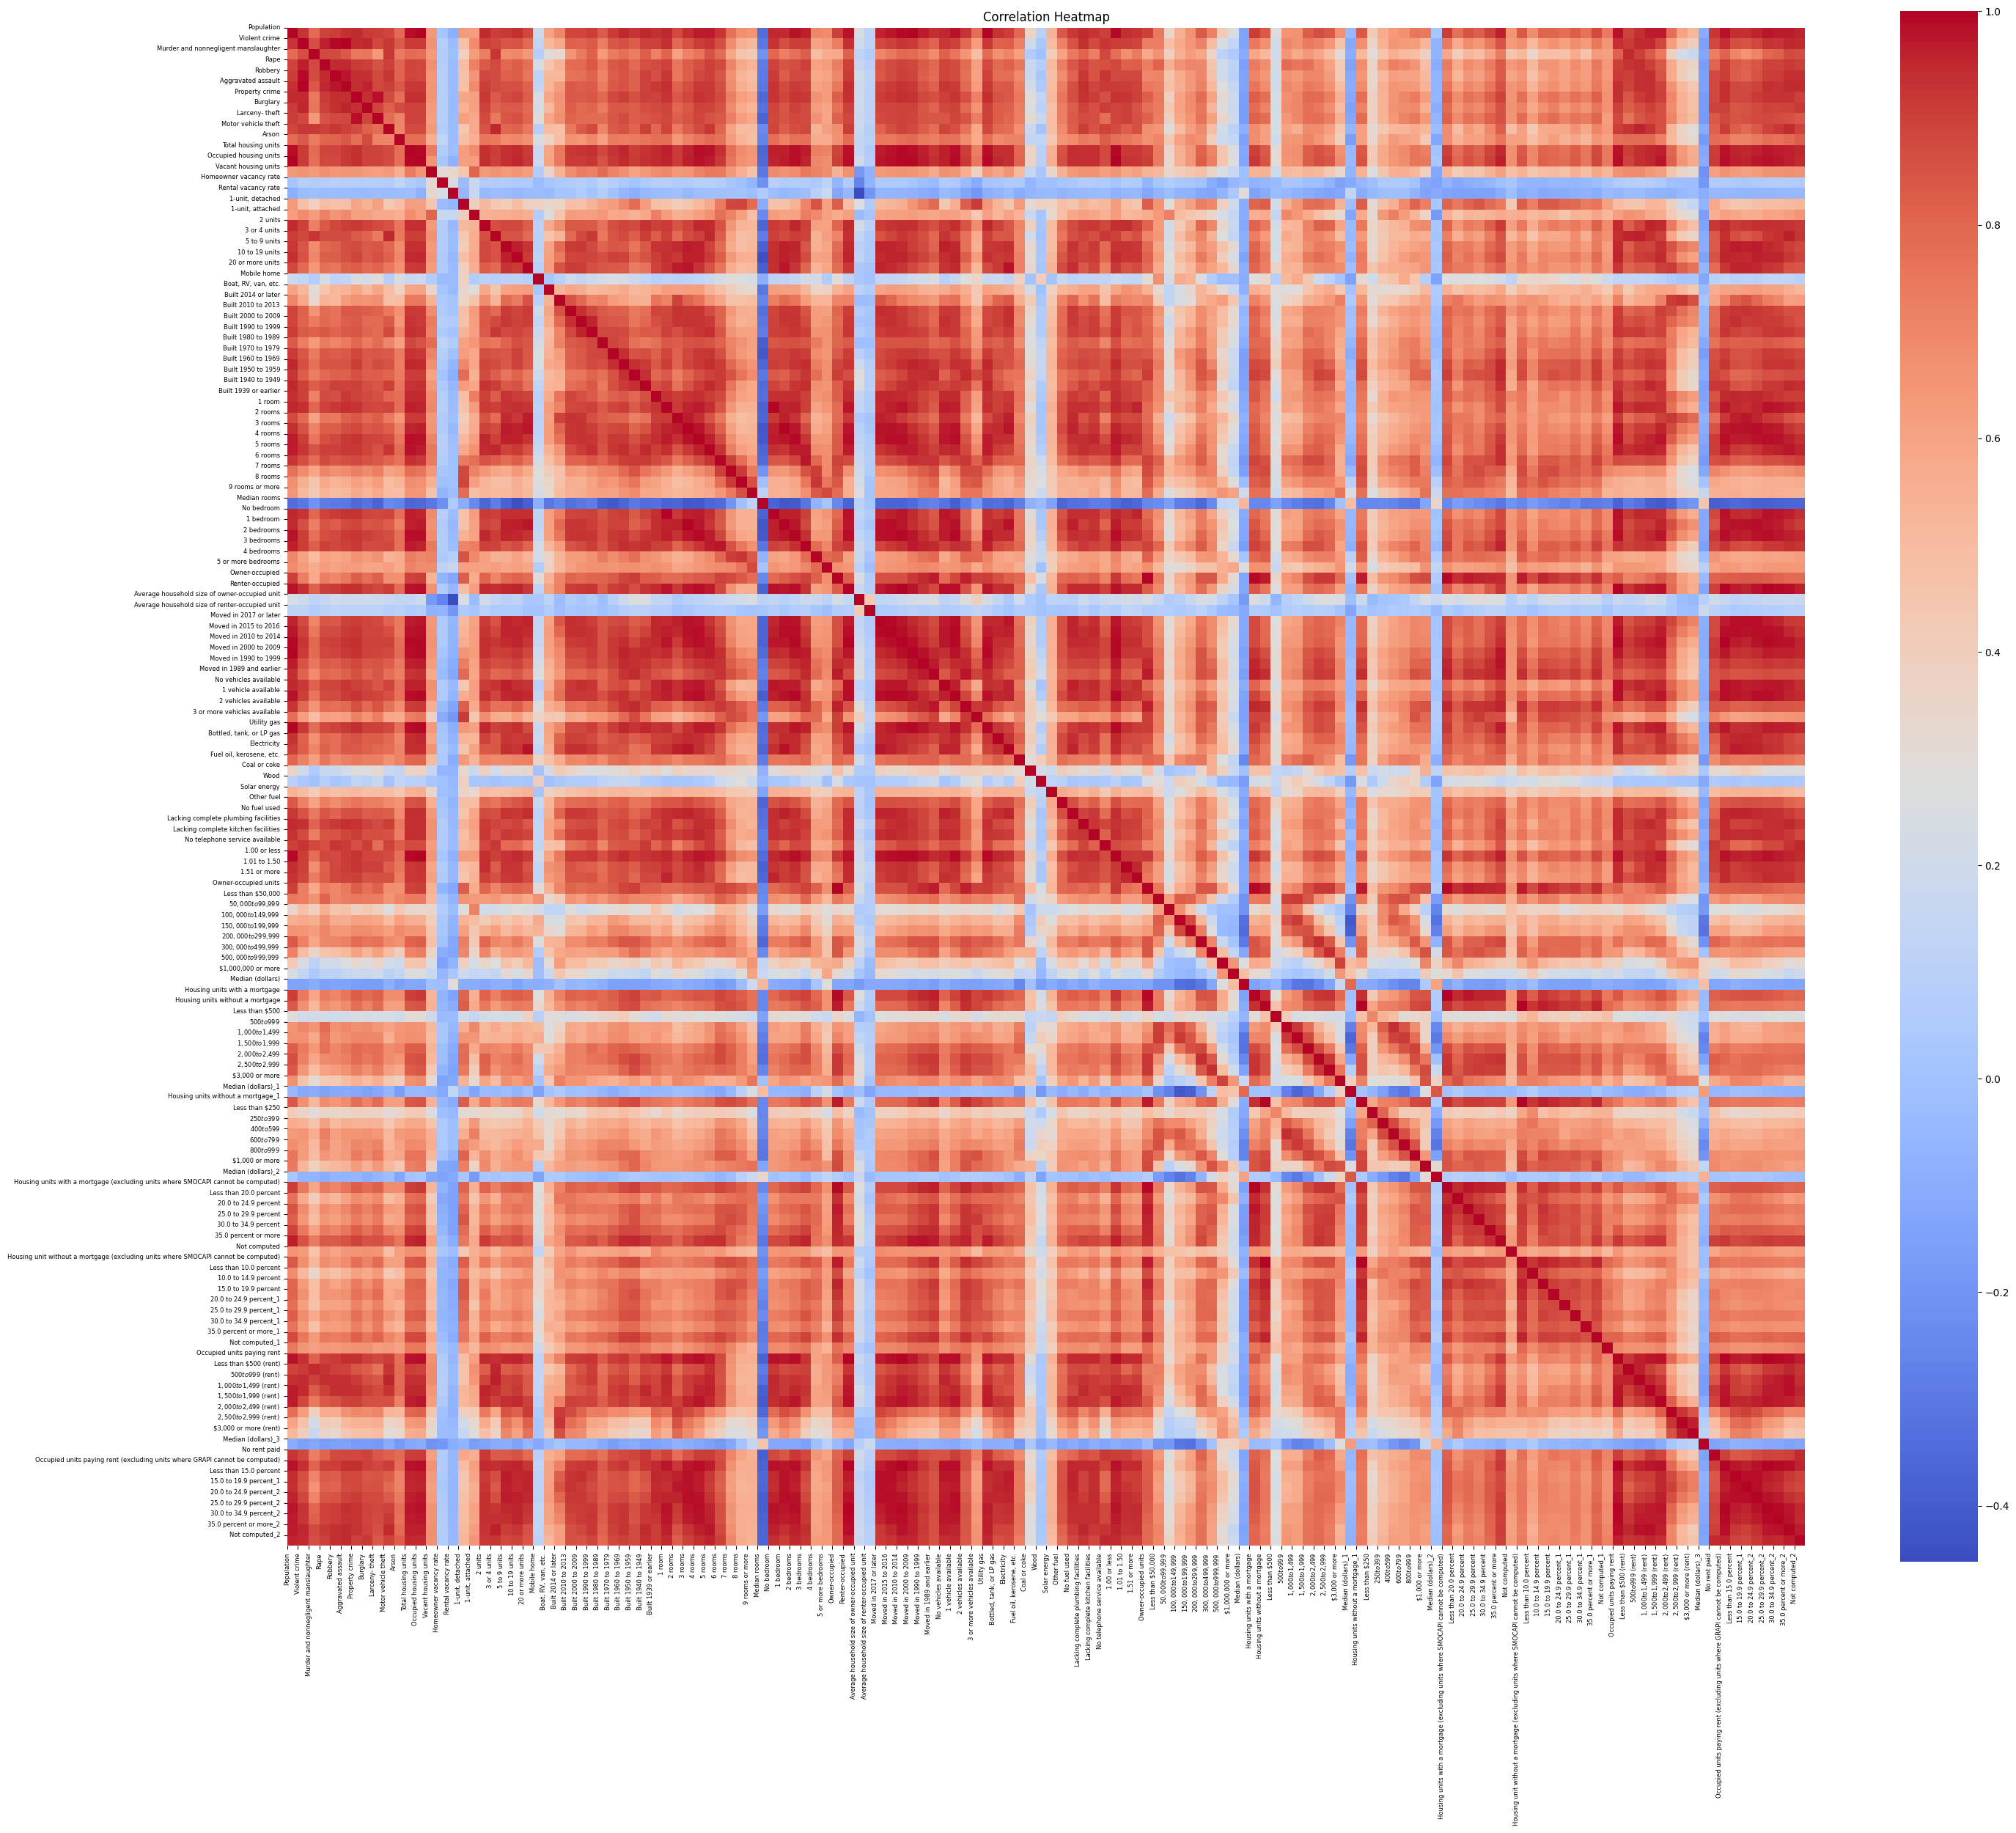

In [785]:
# visualizing data

# histogram
import matplotlib.pyplot as plt
import numpy as np

# gather all columns that have to do with rent prices
rent_cols = [
  "Less than $500 (rent)",
  "$500 to $999 (rent)",
  "$1,000 to $1,499 (rent)",
  "$1,500 to $1,999 (rent)",
  "$2,000 to $2,499 (rent)",
  "$2,500 to $2,999 (rent)",
  "$3,000 or more (rent)",
]

# gather all columns that have to do with house value
house_cols = [
  "Less than $50,000",
  "$50,000 to $99,999",
  "$100,000 to $149,999",
  "$150,000 to $199,999",
  "$200,000 to $299,999",
  "$300,000 to $499,999",
  "$500,000 to $999,999",
  "$1,000,000 or more",
]

# get the sum for each bin
rent_totals = merged_df[rent_cols].sum()
house_totals = merged_df[house_cols].sum()

# plot rent prices
rent_totals.plot()
plt.title("Rent Distribution")
plt.xlabel("Rent Range")
plt.ylabel("Total Units")
plt.xticks(rotation=45)
plt.show()

# plot house prices
house_totals.plot()
plt.title("House Value Distribution")
plt.xlabel("House Value Range")
plt.ylabel("Total Units")
plt.xticks(rotation=45)
plt.show()

# after preprocessing, the rent prices were found to be right skewed and house prices were found to be
# left skewed. This also means that both target values have some outliers.
# This means that a model would be biased towards the high rent prices which can lead to overestimated rent.
# The model would also be biased towards low house values which can lead to underpriced houses.

# heat map
import seaborn as sns

# correlation for the heatmap
corr = merged_df.corr(numeric_only=True)

plt.figure(figsize=(30, 25))

ax = sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False,
    square=True
)

# force every label to show and align properly
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticklabels(corr.columns, fontsize=6)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()